In [5]:
# Cell 1 — Mount Drive and install dependencies
from google.colab import drive
drive.mount('/content/drive')

import subprocess
result = subprocess.run(
    ['pip', 'install', '-r',
     '/content/drive/MyDrive/terranova-disaster-recovery/requirements.txt',
     '-q'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr if result.returncode != 0 else "All packages installed")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

All packages installed


In [2]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/1

In [14]:
!pip uninstall numpy scikit-learn -y
!pip install numpy scikit-learn

Found existing installation: numpy 2.4.5
Uninstalling numpy-2.4.5:
  Successfully uninstalled numpy-2.4.5
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
  Using cached numpy-2.4.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 25.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.5 which is incompatible.


In [1]:
import numpy as np
print(np.__version__)
import sklearn
print(sklearn.__version__)

2.4.5
1.8.0


In [2]:
# Cell 2 — Imports and environment setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import optuna
import joblib
from optuna.samplers import TPESampler
from pathlib import Path
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Kill joblib multiprocessing before anything spawns
os.environ['LOKY_MAX_CPU_COUNT'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

print("Imports complete")


Imports complete


In [3]:
# Cell 3 — Verify GPU
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

try:
    import torch
    if torch.cuda.is_available():
        DEVICE = 'cuda'
        print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    else:
        DEVICE = 'cpu'
        print("No GPU — using CPU")
except ImportError:
    DEVICE = 'cpu'
    print("torch not available — using CPU")

print(f"Device: {DEVICE}")


FileNotFoundError: [Errno 2] No such file or directory: 'nvidia-smi'

In [4]:
# Cell 4 — Paths and configuration
# Update ROOT_DIR if your Drive folder structure is different
ROOT_DIR          = Path('/content/drive/MyDrive/terranova-disaster-recovery')
DATA_DIR          = ROOT_DIR / 'data'
ENGINEERED_DATA_DIR = DATA_DIR / 'engineered'
MODELS_DIR        = ROOT_DIR / 'models'
PLOTS_DIR         = ROOT_DIR / 'plots'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_NAME = 'disaster_cost_forecasting'
mlflow.set_experiment(EXPERIMENT_NAME)

TARGET     = 'total_disaster_cost'
LOG_TARGET = 'log_total_cost'

NUMERICAL_FEATURES = [
    'fyDeclared', 'designatedArea_count',
    'ihProgramDeclared', 'iaProgramDeclared',
    'paProgramDeclared', 'hmProgramDeclared',
    'declaration_month', 'declaration_quarter',
    'historical_median_cost', 'historical_project_count',
    'historical_large_project_count',
    'historical_median_ihp', 'historical_median_ha',
    'historical_median_ona', 'historical_median_pa',
    'historical_median_hmgp', 'historical_median_catab',
    'historical_median_catc2g',
]

CATEGORICAL_FEATURES = ['incidentType', 'declarationType']
DATE_FEATURES        = ['declarationDate', 'incidentBeginDate']

TUNABLE_MODELS = ['random_forest', 'gradient_boosting', 'xgboost', 'lightgbm', 'ridge', 'lasso']
GPU_MODELS     = ['xgboost', 'lightgbm']

print(f"ROOT_DIR         : {ROOT_DIR}")
print(f"ENGINEERED_DATA  : {ENGINEERED_DATA_DIR}")
print(f"MODELS_DIR       : {MODELS_DIR}")
print(f"PLOTS_DIR        : {PLOTS_DIR}")


2026/05/17 18:53:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/17 18:53:18 INFO mlflow.store.db.utils: Updating database tables
2026/05/17 18:53:21 INFO mlflow.tracking.fluent: Experiment with name 'disaster_cost_forecasting' does not exist. Creating a new experiment.


ROOT_DIR         : /content/drive/MyDrive/terranova-disaster-recovery
ENGINEERED_DATA  : /content/drive/MyDrive/terranova-disaster-recovery/data/engineered
MODELS_DIR       : /content/drive/MyDrive/terranova-disaster-recovery/models
PLOTS_DIR        : /content/drive/MyDrive/terranova-disaster-recovery/plots


In [5]:
# Cell 5 — Date feature extractors
def extract_declaration_month(X):
    return pd.to_datetime(X['declarationDate'], utc=True).dt.month.values.reshape(-1, 1)

def extract_declaration_quarter(X):
    return pd.to_datetime(X['declarationDate'], utc=True).dt.quarter.values.reshape(-1, 1)

def extract_incident_month(X):
    return pd.to_datetime(X['incidentBeginDate'], utc=True).dt.month.values.reshape(-1, 1)

def extract_incident_quarter(X):
    return pd.to_datetime(X['incidentBeginDate'], utc=True).dt.quarter.values.reshape(-1, 1)


print("Date extractors defined")


Date extractors defined


In [6]:
# Cell 6 — Preprocessor builder
def build_preprocessor(numerical_features, categorical_features, date_features):
    transformers = [
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(
            drop='first', handle_unknown='ignore', sparse_output=False
        ), categorical_features),
    ]
    if 'declarationDate' in date_features:
        transformers += [
            ('decl_month',   FunctionTransformer(extract_declaration_month),   date_features),
            ('decl_quarter', FunctionTransformer(extract_declaration_quarter), date_features),
        ]
    if 'incidentBeginDate' in date_features:
        transformers += [
            ('inc_month',   FunctionTransformer(extract_incident_month),   date_features),
            ('inc_quarter', FunctionTransformer(extract_incident_quarter), date_features),
        ]

    return ColumnTransformer(transformers=transformers, remainder='drop')

print("Preprocessor builder defined")


Preprocessor builder defined


In [7]:
# Cell 7 — Load and prepare data
df = pd.read_csv(ENGINEERED_DATA_DIR / 'disaster_costs.csv')
print(f"Loaded shape: {df.shape}")

# Drop leakage columns
leakage_cols = [
    'total_obligated', 'federal_obligated', 'avg_project_cost',
    'applicant_count', 'project_count', 'large_project_count',
    'small_project_count', 'disasterNumber', 'incidentEndDate'
]
found = [c for c in leakage_cols if c in df.columns]
if found:
    print(f"Dropping leakage: {found}")
    df = df.drop(columns=found)

print(f"Null target  : {df[TARGET].isna().sum()}")
print(f"Zero target  : {(df[TARGET] == 0).sum()}")
print(f"Negative     : {(df[TARGET] < 0).sum()}")

df = df.dropna(subset=[TARGET])
df[TARGET] = df[TARGET].clip(lower=0)
df[LOG_TARGET] = np.log1p(df[TARGET])

assert df[LOG_TARGET].isna().sum() == 0
assert np.isinf(df[LOG_TARGET]).sum() == 0

available_num  = [f for f in NUMERICAL_FEATURES  if f in df.columns]
available_cat  = [f for f in CATEGORICAL_FEATURES if f in df.columns]
available_date = [f for f in DATE_FEATURES        if f in df.columns]

missing_num  = [f for f in NUMERICAL_FEATURES  if f not in df.columns]
missing_cat  = [f for f in CATEGORICAL_FEATURES if f not in df.columns]
missing_date = [f for f in DATE_FEATURES        if f not in df.columns]

if missing_num:  print(f"Missing numerical : {missing_num}")
if missing_cat:  print(f"Missing categorical: {missing_cat}")
if missing_date: print(f"Missing date      : {missing_date}")

X = df[available_num + available_cat + available_date]
y = df[LOG_TARGET]

null_check = X.isna().sum()
null_check = null_check[null_check > 0]
if len(null_check) > 0:
    print(f"WARNING — nulls in features:\n{null_check}")

print(f"\nFeature matrix : {X.shape}")
print(f"Target summary :\n{y.describe()}")


Loaded shape: (3940, 50)
Dropping leakage: ['total_obligated', 'federal_obligated', 'avg_project_cost', 'applicant_count', 'project_count', 'large_project_count', 'small_project_count', 'disasterNumber']
Null target  : 0
Zero target  : 838
Negative     : 1

Feature matrix : (3940, 22)
Target summary :
count    3940.000000
mean       11.798903
std         6.569018
min         0.000000
25%        10.122720
50%        14.360366
75%        16.183143
max        24.349120
Name: log_total_cost, dtype: float64


In [6]:
# Cell 8 — Time-based train/test split
df_sorted_idx = df.sort_values('fyDeclared').index
X = X.loc[df_sorted_idx]
y = y.loc[df_sorted_idx]

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train : {len(X_train)} rows | "
      f"{df.loc[X_train.index,'fyDeclared'].min()} - {df.loc[X_train.index,'fyDeclared'].max()}")
print(f"Test  : {len(X_test)}  rows | "
      f"{df.loc[X_test.index,'fyDeclared'].min()} - {df.loc[X_test.index,'fyDeclared'].max()}")


Train : 3152 rows | 1970 - 2020
Test  : 788  rows | 2020 - 2026


In [7]:
# Cell 9 — Shared metric computation
def compute_metrics(y_test, y_pred_log):
    r2   = r2_score(y_test, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae  = mean_absolute_error(y_test, y_pred_log)

    y_pred_dollars = np.expm1(y_pred_log)
    y_test_dollars = np.expm1(y_test)
    rmse_dollars   = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
    mae_dollars    = mean_absolute_error(y_test_dollars, y_pred_dollars)

    return dict(r2=r2, rmse=rmse, mae=mae,
                rmse_dollars=rmse_dollars, mae_dollars=mae_dollars)

def manual_cv(estimator, X, y, kf):
    """Pure Python CV — zero joblib, safe on Colab GPU."""
    scores = []
    X_arr = X if isinstance(X, np.ndarray) else X.values
    y_arr = y.values if hasattr(y, 'values') else y
    for tr_idx, val_idx in kf.split(X_arr):
        estimator.fit(X_arr[tr_idx], y_arr[tr_idx])
        scores.append(r2_score(y_arr[val_idx], estimator.predict(X_arr[val_idx])))
    return np.array(scores)

print("Metric helpers defined")


Metric helpers defined


In [9]:
if 'DEVICE' not in dir():
    try:
        import torch
        DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    except ImportError:
        DEVICE = 'cpu'
    print(f"DEVICE set to: {DEVICE}")


DEVICE set to: cuda


In [10]:
# Cell 10 — Model definitions
models = {
    'linear_regression': LinearRegression(),
    'ridge':             Ridge(alpha=1.0),
    'lasso':             Lasso(alpha=1.0),
    'random_forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'gradient_boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'xgboost': XGBRegressor(
        n_estimators=100, random_state=42,
        device=DEVICE, tree_method='hist',
        eval_metric='rmse', verbosity=0,
    ),
    'lightgbm': LGBMRegressor(
        n_estimators=100, random_state=42,
        device='gpu' if DEVICE == 'cuda' else 'cpu',
        verbosity=-1,
    ),
}

results    = {}
best_params = {}
print("Models defined:", list(models.keys()))


Models defined: ['linear_regression', 'ridge', 'lasso', 'random_forest', 'gradient_boosting', 'xgboost', 'lightgbm']


In [11]:
# Cell 11 — Baseline training (all models)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    is_gpu = model_name in GPU_MODELS and DEVICE == 'cuda'

    with mlflow.start_run(run_name=model_name):
        if is_gpu:
            # Preprocess once — pass numpy arrays directly to GPU model
            pre = build_preprocessor(available_num, available_cat, available_date)
            X_tr_proc = pre.fit_transform(X_train)
            X_te_proc = pre.transform(X_test)
            model.fit(X_tr_proc, y_train)
            cv_scores = manual_cv(model, X_tr_proc, y_train, kf)
            metrics   = compute_metrics(y_test, model.predict(X_te_proc))
            results[model_name] = {
                'preprocessor': pre, 'model': model,
                'cv_r2_mean': cv_scores.mean(), 'cv_r2_std': cv_scores.std(),
                **metrics
            }
            device_label = DEVICE.upper()
        else:
            pipeline = Pipeline([
                ('preprocessor', build_preprocessor(available_num, available_cat, available_date)),
                ('model', model)
            ])
            from sklearn.model_selection import cross_val_score
            cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
            pipeline.fit(X_train, y_train)
            metrics = compute_metrics(y_test, pipeline.predict(X_test))
            results[model_name] = {
                'pipeline': pipeline,
                'cv_r2_mean': cv_scores.mean(), 'cv_r2_std': cv_scores.std(),
                **metrics
            }
            device_label = 'CPU'

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("device", device_label)
        mlflow.log_param("tuned", False)
        mlflow.log_metric("cv_r2_mean",       cv_scores.mean())
        mlflow.log_metric("cv_r2_std",        cv_scores.std())
        mlflow.log_metric("test_r2",          metrics['r2'])
        mlflow.log_metric("test_rmse_dollars", metrics['rmse_dollars'])
        mlflow.log_metric("test_mae_dollars",  metrics['mae_dollars'])

    print(f"\n{'='*40}")
    print(f"Model : {model_name} ({device_label})")
    print(f"CV R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test R²  : {metrics['r2']:.4f}")
    print(f"Test RMSE: ${metrics['rmse_dollars']:,.0f}")
    print(f"Test MAE : ${metrics['mae_dollars']:,.0f}")

print("\nBaseline training complete")


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Model : linear_regression (CPU)
CV R² : 0.2310 ± 0.3584
Test R²  : 0.2049
Test RMSE: $2,081,844,213
Test MAE : $365,383,896


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Model : ridge (CPU)
CV R² : 0.4938 ± 0.0322
Test R²  : 0.1661
Test RMSE: $6,700,763,654,353
Test MAE : $767,125,532,610


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ


Model : gradient_boosting (CPU)
CV R² : 0.6559 ± 0.0352
Test R²  : 0.5026
Test RMSE: $870,048,742
Test MAE : $104,064,419

Model : xgboost (CUDA)
CV R² : 0.6444 ± 0.0465
Test R²  : 0.4742
Test RMSE: $1,337,254,364
Test MAE : $181,140,549


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Model : lightgbm (CUDA)
CV R² : 0.6617 ± 0.0363
Test R²  : 0.5013
Test RMSE: $1,075,425,497
Test MAE : $176,224,446

Baseline training complete


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [12]:
# Cell 12 — Identify top 2 tunable models
ranked = sorted(results.items(), key=lambda x: x[1]['cv_r2_mean'], reverse=True)
top_tunable = [name for name, _ in ranked if name in TUNABLE_MODELS][:2]
print(f"Selected for tuning: {top_tunable}")

# Baseline summary
summary = pd.DataFrame({
    name: {
        'CV R² (mean)': f"{res['cv_r2_mean']:.4f}",
        'CV R² (std)':  f"±{res['cv_r2_std']:.4f}",
        'Test R²':      f"{res['r2']:.4f}",
        'Test RMSE ($)':f"${res['rmse_dollars']:,.0f}",
        'Test MAE ($)': f"${res['mae_dollars']:,.0f}",
    }
    for name, res in results.items()
}).T.sort_values('CV R² (mean)', ascending=False)

print("\nBaseline results:")
print(summary.to_string())


Selected for tuning: ['lightgbm', 'gradient_boosting']

Baseline results:
                  CV R² (mean) CV R² (std) Test R²       Test RMSE ($)      Test MAE ($)
lightgbm                0.6617     ±0.0363  0.5013      $1,075,425,497      $176,224,446
gradient_boosting       0.6559     ±0.0352  0.5026        $870,048,742      $104,064,419
random_forest           0.6529     ±0.0454  0.5506        $863,992,830       $96,286,342
xgboost                 0.6444     ±0.0465  0.4742      $1,337,254,364      $181,140,549
ridge                   0.4938     ±0.0322  0.1661  $6,700,763,654,353  $767,125,532,610
lasso                   0.3032     ±0.0139  0.0541        $900,376,228      $109,530,187
linear_regression       0.2310     ±0.3584  0.2049      $2,081,844,213      $365,383,896


In [13]:
# Cell 13 — Optuna hyperparameter search spaces
def get_optuna_params(trial, model_name):
    if model_name == 'random_forest':
        return {
            'model__n_estimators':    trial.suggest_int('n_estimators', 100, 1000),
            'model__max_depth':       trial.suggest_int('max_depth', 3, 20),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'model__min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
            'model__max_features':    trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
    elif model_name == 'gradient_boosting':
        return {
            'model__n_estimators':    trial.suggest_int('n_estimators', 100, 1000),
            'model__learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'model__max_depth':       trial.suggest_int('max_depth', 2, 8),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'model__min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
            'model__subsample':       trial.suggest_float('subsample', 0.5, 1.0),
            'model__max_features':    trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
    elif model_name == 'xgboost':
        return {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 2, 10),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        }
    elif model_name == 'lightgbm':
        return {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 2, 10),
            'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        }
    elif model_name == 'ridge':
        return {'model__alpha': trial.suggest_float('alpha', 1e-3, 1e3, log=True)}
    elif model_name == 'lasso':
        return {'model__alpha': trial.suggest_float('alpha', 1e-3, 1e3, log=True)}

def build_tuned_model(model_name, params):
    if model_name == 'xgboost':
        return XGBRegressor(random_state=42, device=DEVICE, tree_method='hist', verbosity=0, **params)
    elif model_name == 'lightgbm':
        return LGBMRegressor(random_state=42, device='gpu' if DEVICE == 'cuda' else 'cpu', verbosity=-1, **params)
    elif model_name == 'random_forest':
        return RandomForestRegressor(random_state=42, n_jobs=-1, **{k.replace('model__',''): v for k,v in params.items()})
    elif model_name == 'gradient_boosting':
        return GradientBoostingRegressor(random_state=42, **{k.replace('model__',''): v for k,v in params.items()})
    elif model_name == 'ridge':
        return Ridge(**{k.replace('model__',''): v for k,v in params.items()})
    elif model_name == 'lasso':
        return Lasso(**{k.replace('model__',''): v for k,v in params.items()})

print("Optuna helpers defined")


Optuna helpers defined


In [14]:
# Cell 14 — Optuna tuning for top models
N_TRIALS = 20
optuna.logging.set_verbosity(optuna.logging.WARNING)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name in top_tunable:
    is_gpu = model_name in GPU_MODELS and DEVICE == 'cuda'
    print(f"\nTuning {model_name} ({N_TRIALS} trials)...")

    if is_gpu:
        # Preprocess once — reuse across all 250 fits
        pre = build_preprocessor(available_num, available_cat, available_date)
        X_tr_proc = pre.fit_transform(X_train)
        print(f"Preprocessed shape: {X_tr_proc.shape}")

        def objective(trial):
            params = get_optuna_params(trial, model_name)
            if model_name == 'xgboost':
                base = XGBRegressor(
                    random_state=42, device='cuda',
                    tree_method='hist', verbosity=0, **params
                )
            else:
                base = LGBMRegressor(
                    random_state=42, device='gpu',
                    verbosity=-1, n_jobs=1, **params
                )
            # Manual CV — no joblib, no semaphore leaks
            return manual_cv(base, X_tr_proc, y_train, kf).mean()

    else:
        def objective(trial):
            params = get_optuna_params(trial, model_name)
            if model_name == 'random_forest':
                base = RandomForestRegressor(random_state=42, n_jobs=1)
            elif model_name == 'gradient_boosting':
                base = GradientBoostingRegressor(random_state=42)
            elif model_name == 'ridge':
                base = Ridge()
            elif model_name == 'lasso':
                base = Lasso()

            y_arr = y_train.values
            scores = []
            for tr_idx, val_idx in kf.split(X_train):
                X_tr_raw = X_train.iloc[tr_idx]
                X_val_raw = X_train.iloc[val_idx]
                fold_pre = build_preprocessor(available_num, available_cat, available_date)
                X_tr  = fold_pre.fit_transform(X_tr_raw)
                X_val = fold_pre.transform(X_val_raw)
                base.set_params(**{k.replace('model__', ''): v for k, v in params.items()})
                base.fit(X_tr, y_arr[tr_idx])
                scores.append(r2_score(y_arr[val_idx], base.predict(X_val)))
            return np.mean(scores)

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print(f"Best CV R²  : {study.best_value:.4f}")
    print(f"Best params : {study.best_params}")

    best_params[model_name] = study.best_params
    tuned_model = build_tuned_model(model_name, study.best_params)
    run_name = f"{model_name}_tuned"

    with mlflow.start_run(run_name=run_name):
        if is_gpu:
            best_params[f'{model_name}_preprocessor'] = pre
            X_te_proc = pre.transform(X_test)
            tuned_model.fit(X_tr_proc, y_train)
            cv_scores = manual_cv(tuned_model, X_tr_proc, y_train, kf)
            metrics   = compute_metrics(y_test, tuned_model.predict(X_te_proc))
            results[run_name] = {
                'preprocessor': pre, 'model': tuned_model,
                'cv_r2_mean': cv_scores.mean(), 'cv_r2_std': cv_scores.std(),
                **metrics
            }
            device_label = DEVICE.upper()
        else:
            pipeline = Pipeline([
                ('preprocessor', build_preprocessor(available_num, available_cat, available_date)),
                ('model', tuned_model)
            ])
            from sklearn.model_selection import cross_val_score
            cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
            pipeline.fit(X_train, y_train)
            metrics = compute_metrics(y_test, pipeline.predict(X_test))
            results[run_name] = {
                'pipeline': pipeline,
                'cv_r2_mean': cv_scores.mean(), 'cv_r2_std': cv_scores.std(),
                **metrics
            }
            device_label = 'CPU'

        mlflow.log_param("model_name", run_name)
        mlflow.log_param("device", device_label)
        mlflow.log_param("tuned", True)
        mlflow.log_params(study.best_params)
        mlflow.log_metric("cv_r2_mean",        cv_scores.mean())
        mlflow.log_metric("cv_r2_std",         cv_scores.std())
        mlflow.log_metric("test_r2",           metrics['r2'])
        mlflow.log_metric("test_rmse_dollars", metrics['rmse_dollars'])
        mlflow.log_metric("test_mae_dollars",  metrics['mae_dollars'])

    print(f"\n{'='*40}")
    print(f"Model : {run_name} ({device_label})")
    print(f"CV R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test R²  : {metrics['r2']:.4f}")
    print(f"Test RMSE: ${metrics['rmse_dollars']:,.0f}")
    print(f"Test MAE : ${metrics['mae_dollars']:,.0f}")

print("\nTuning complete")



Tuning lightgbm (20 trials)...
Preprocessed shape: (3152, 46)


  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

Best CV R²  : 0.6718
Best params : {'n_estimators': 997, 'learning_rate': 0.010425658055299656, 'max_depth': 9, 'num_leaves': 67, 'subsample': 0.9791430054191069, 'colsample_bytree': 0.8898630426456755, 'reg_alpha': 2.776274882639467, 'reg_lambda': 0.04705614323574565, 'min_child_samples': 50}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

...

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Best CV R²  : 0.6739
Best params : {'n_estimators': 853, 'learning_rate': 0.019327189948056874, 'max_depth': 4, 'min_samples_split': 10, 'min_samples_leaf': 10, 'subsample': 0.6502908546455145, 'max_features': None}


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Model : gradient_boosting_tuned (CPU)
CV R² : 0.6739 ± 0.0354
Test R²  : 0.4968
Test RMSE: $4,130,848,655
Test MAE : $450,007,255

Tuning complete


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [17]:
# Cell 15 — Final model comparison
summary_all = pd.DataFrame({
    name: {
        'CV R² (mean)': f"{res['cv_r2_mean']:.4f}",
        'CV R² (std)':  f"±{res['cv_r2_std']:.4f}",
        'Test R²':      f"{res['r2']:.4f}",
        'Test RMSE ($)':f"${res['rmse_dollars']:,.0f}",
        'Test MAE ($)': f"${res['mae_dollars']:,.0f}",
    }
    for name, res in results.items()
}).T.sort_values('Test R²', ascending=False)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON — ranked by CV R²")
print("="*60)
print(summary_all.to_string())

best_model_name = max(results, key=lambda x: results[x]['r2'])
print(f"\nBest model: {best_model_name}")



FINAL MODEL COMPARISON — ranked by CV R²
                        CV R² (mean) CV R² (std) Test R²       Test RMSE ($)      Test MAE ($)
random_forest                 0.6529     ±0.0454  0.5506        $863,992,830       $96,286,342
gradient_boosting             0.6559     ±0.0352  0.5026        $870,048,742      $104,064,419
lightgbm                      0.6617     ±0.0363  0.5013      $1,075,425,497      $176,224,446
gradient_boosting_tuned       0.6739     ±0.0354  0.4968      $4,130,848,655      $450,007,255
lightgbm_tuned                0.6718     ±0.0393  0.4884        $882,202,574      $123,047,027
xgboost                       0.6444     ±0.0465  0.4742      $1,337,254,364      $181,140,549
linear_regression             0.2310     ±0.3584  0.2049      $2,081,844,213      $365,383,896
ridge                         0.4938     ±0.0322  0.1661  $6,700,763,654,353  $767,125,532,610
lasso                         0.3032     ±0.0139  0.0541        $900,376,228      $109,530,187

Best mo

In [18]:
# Cell 16 — Save best model to Drive
best_result = results[best_model_name]

if 'pipeline' in best_result:
    save_path = MODELS_DIR / f'{best_model_name}_pipeline.pkl'
    joblib.dump(best_result['pipeline'], save_path)
    print(f"Saved pipeline : {save_path}")
else:
    pre_path   = MODELS_DIR / f'{best_model_name}_preprocessor.pkl'
    model_path = MODELS_DIR / f'{best_model_name}_model.pkl'
    joblib.dump(best_result['preprocessor'], pre_path)
    joblib.dump(best_result['model'],        model_path)
    print(f"Saved preprocessor : {pre_path}")
    print(f"Saved model        : {model_path}")

metadata = {
    'model_name':        best_model_name,
    'cv_r2_mean':        best_result['cv_r2_mean'],
    'cv_r2_std':         best_result['cv_r2_std'],
    'test_r2':           best_result['r2'],
    'test_rmse_dollars': best_result['rmse_dollars'],
    'test_mae_dollars':  best_result['mae_dollars'],
    'numerical_features':   available_num,
    'categorical_features': available_cat,
    'date_features':        available_date,
    'target':     TARGET,
    'log_target': LOG_TARGET,
    'device':     DEVICE,
    'is_gpu_model': best_model_name.replace('_tuned','') in GPU_MODELS,
}
meta_path = MODELS_DIR / f'{best_model_name}_metadata.pkl'
joblib.dump(metadata, meta_path)
print(f"Saved metadata     : {meta_path}")
print(f"\nAll model files in : {MODELS_DIR}")


Saved pipeline : /content/drive/MyDrive/terranova-disaster-recovery/models/random_forest_pipeline.pkl
Saved metadata     : /content/drive/MyDrive/terranova-disaster-recovery/models/random_forest_metadata.pkl

All model files in : /content/drive/MyDrive/terranova-disaster-recovery/models


In [19]:
# Cell 17 — Save all plots to Drive
best_result = results[best_model_name]

if 'pipeline' in best_result:
    y_pred_log = best_result['pipeline'].predict(X_test)
else:
    X_te_proc  = best_result['preprocessor'].transform(X_test)
    y_pred_log = best_result['model'].predict(X_te_proc)

y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test)
errors         = np.abs(y_test_dollars.values - y_pred_dollars)

# ── Plot 1 — Actual vs Predicted ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_dollars, y_pred_dollars, alpha=0.3, color='steelblue')
max_val = max(y_test_dollars.max(), y_pred_dollars.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect fit')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Actual cost ($)'); ax.set_ylabel('Predicted cost ($)')
ax.set_title(f'Actual vs Predicted — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'{best_model_name}_actual_vs_predicted.png', dpi=150)
plt.close()
print("Saved: actual_vs_predicted.png")

# ── Plot 2 — Residuals ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
residuals = y_test_dollars.values - y_pred_dollars
ax.scatter(y_pred_dollars, residuals, alpha=0.3, color='coral')
ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.set_xscale('log')
ax.set_xlabel('Predicted cost ($)'); ax.set_ylabel('Residual ($)')
ax.set_title(f'Residuals — {best_model_name}')
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'{best_model_name}_residuals.png', dpi=150)
plt.close()
print("Saved: residuals.png")

# ── Plot 3 — Error distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(np.log1p(errors), bins=50, color='steelblue', edgecolor='white')
ax.axvline(np.log1p(np.median(errors)), color='red', linestyle='--',
           label=f'Median: ${np.median(errors):,.0f}')
ax.set_xlabel('Log absolute error'); ax.set_ylabel('Count')
ax.set_title(f'Error distribution — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'{best_model_name}_error_distribution.png', dpi=150)
plt.close()
print("Saved: error_distribution.png")

# ── Plot 4 — Model comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
names    = list(results.keys())
cv_r2    = [results[n]['cv_r2_mean'] for n in names]
test_r2  = [results[n]['r2']         for n in names]
colors   = ['seagreen' if n == best_model_name else 'steelblue' for n in names]

axes[0].barh(names, cv_r2,   color=colors); axes[0].set_xlabel('CV R²')
axes[0].set_title('CV R² by model'); axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[1].barh(names, test_r2, color=colors); axes[1].set_xlabel('Test R²')
axes[1].set_title('Test R² by model'); axes[1].axvline(x=0, color='black', linewidth=0.5)
plt.suptitle('Model comparison (green = best)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'model_comparison.png', dpi=150)
plt.close()
print("Saved: model_comparison.png")

# ── Plot 5 — Feature importance (tree models only) ────────────────────────
model_obj = best_result.get('model') or best_result.get('pipeline', {}).named_steps.get('model')
if hasattr(model_obj, 'feature_importances_'):
    importances = model_obj.feature_importances_
    n = min(20, len(importances))
    indices = np.argsort(importances)[-n:]
    labels  = [f'feature_{i}' for i in range(len(importances))]
    if 'pipeline' in best_result:
        try:
            labels = list(best_result['pipeline']
                          .named_steps['preprocessor']
                          .get_feature_names_out())
        except Exception:
            pass
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh([labels[i] if i < len(labels) else f'feature_{i}' for i in indices],
            importances[indices], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {n} feature importances — {best_model_name}')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'{best_model_name}_feature_importance.png', dpi=150)
    plt.close()
    print("Saved: feature_importance.png")

print(f"\nAll plots saved to: {PLOTS_DIR}")


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Saved: actual_vs_predicted.png
Saved: residuals.png
Saved: error_distribution.png
Saved: model_comparison.png
Saved: feature_importance.png

All plots saved to: /content/drive/MyDrive/terranova-disaster-recovery/plots


In [ ]:
# Cell 18 — Load and run inference (run this anytime after training)
import joblib, numpy as np

meta      = joblib.load(MODELS_DIR / f'{best_model_name}_metadata.pkl')
is_gpu    = meta['is_gpu_model']

if is_gpu:
    pre   = joblib.load(MODELS_DIR / f'{best_model_name}_preprocessor.pkl')
    model = joblib.load(MODELS_DIR / f'{best_model_name}_model.pkl')
    def predict(X_new):
        return np.expm1(model.predict(pre.transform(X_new)))
else:
    pipeline = joblib.load(MODELS_DIR / f'{best_model_name}_pipeline.pkl')
    def predict(X_new):
        return np.expm1(pipeline.predict(X_new))

# Quick sanity check on test set
preds = predict(X_test)
print(f"Sample predictions (first 5): {preds[:5]}")
print(f"Sample actuals    (first 5): {np.expm1(y_test.values[:5])}")
print(f"\nModel metadata:")
for k, v in meta.items():
    if k not in ['numerical_features', 'categorical_features', 'date_features']:
        print(f"  {k}: {v}")


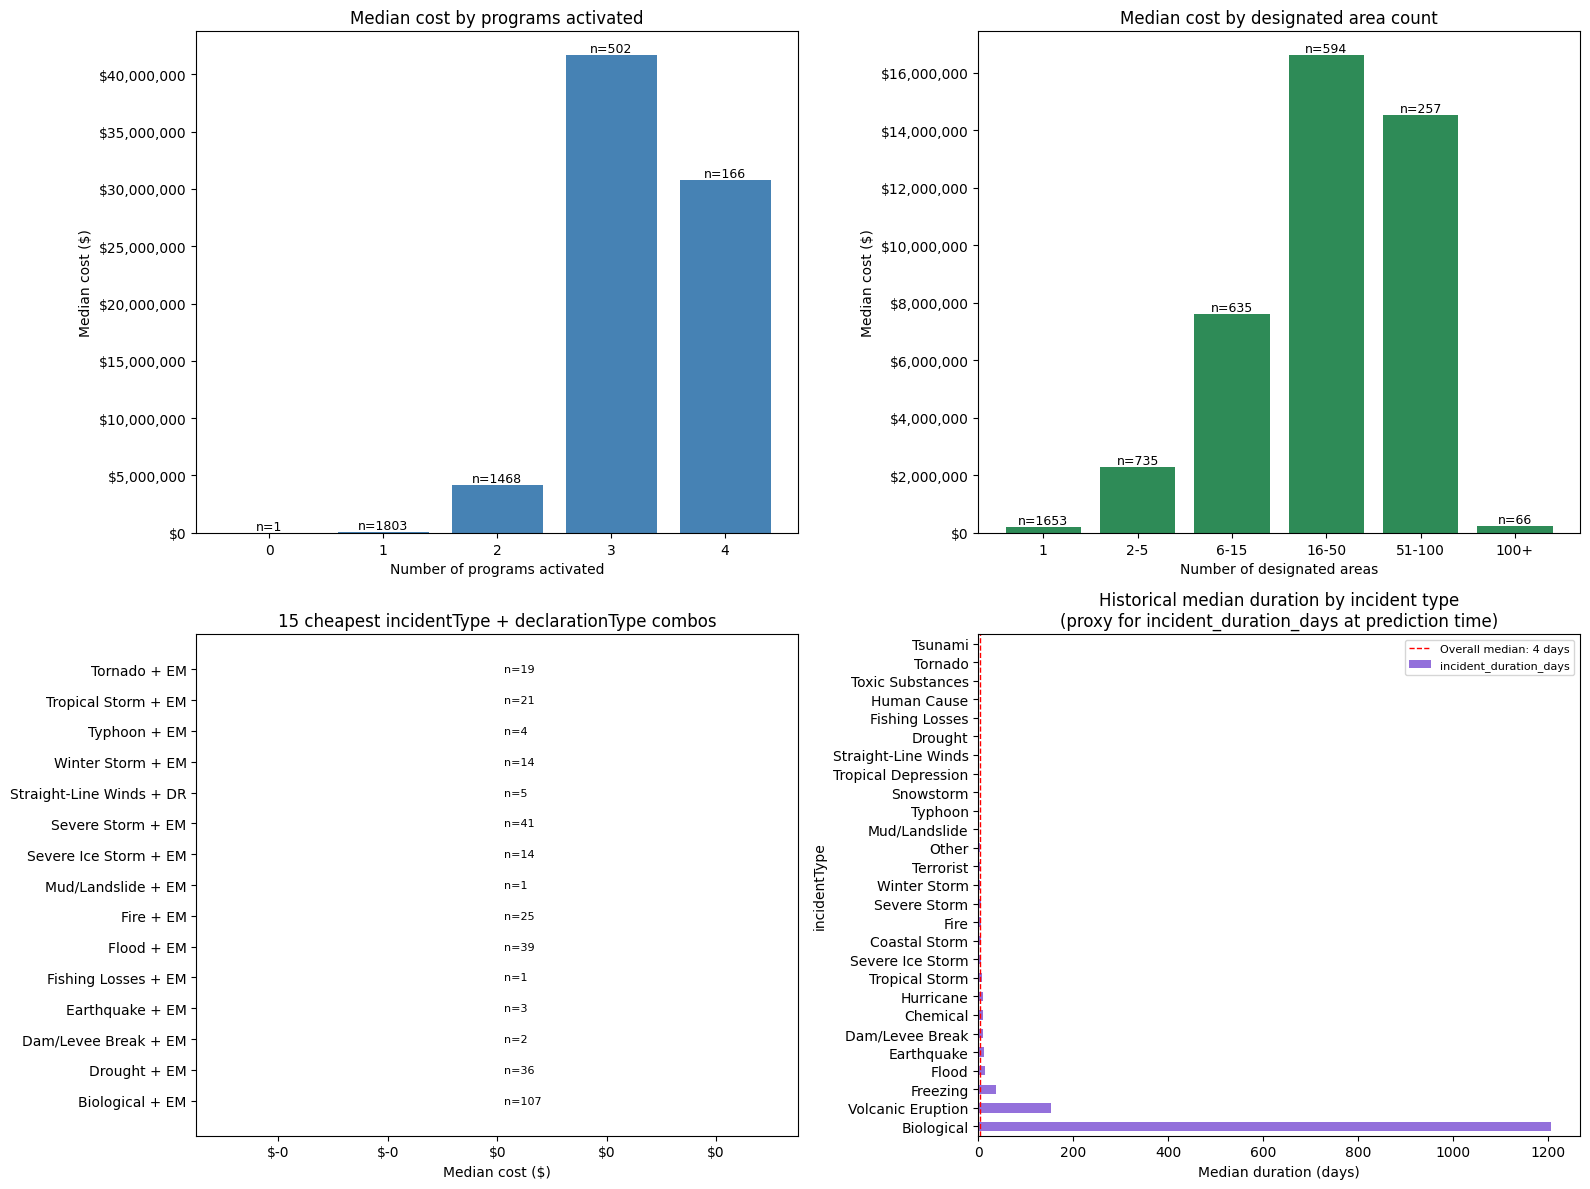

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1 — Programs activated vs median cost ─────────────────────────────
df['programs_activated'] = (
    df['ihProgramDeclared'] +
    df['iaProgramDeclared'] +
    df['paProgramDeclared'] +
    df['hmProgramDeclared']
)

prog_cost = df.groupby('programs_activated')['total_disaster_cost'].median()
prog_count = df.groupby('programs_activated').size()

ax = axes[0, 0]
bars = ax.bar(prog_cost.index.astype(str), prog_cost.values, color='steelblue')
ax.set_xlabel('Number of programs activated')
ax.set_ylabel('Median cost ($)')
ax.set_title('Median cost by programs activated')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add count labels on bars
for bar, count in zip(bars, prog_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'n={count}', ha='center', va='bottom', fontsize=9)

# ── Plot 2 — designatedArea_count vs cost (binned) ────────────────────────
ax = axes[0, 1]

# Bin designated areas into meaningful buckets
bins = [0, 1, 5, 15, 50, 100, 500]
labels = ['1', '2-5', '6-15', '16-50', '51-100', '100+']
df['area_bin'] = pd.cut(
    df['designatedArea_count'],
    bins=bins, labels=labels, include_lowest=True
)

area_cost  = df.groupby('area_bin', observed=True)['total_disaster_cost'].median()
area_count = df.groupby('area_bin', observed=True).size()

bars = ax.bar(area_cost.index.astype(str), area_cost.values, color='seagreen')
ax.set_xlabel('Number of designated areas')
ax.set_ylabel('Median cost ($)')
ax.set_title('Median cost by designated area count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar, count in zip(bars, area_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'n={count}', ha='center', va='bottom', fontsize=9)

# ── Plot 3 — Cheap combos: incidentType + declarationType median cost ──────
ax = axes[1, 0]

combo_cost = (df
    .groupby(['incidentType', 'declarationType'])['total_disaster_cost']
    .agg(['median', 'count'])
    .reset_index()
)
combo_cost['combo'] = combo_cost['incidentType'] + ' + ' + combo_cost['declarationType']

# Sort by median cost — show bottom 15 cheapest combos
cheapest = combo_cost.sort_values('median').head(15)

ax.barh(cheapest['combo'], cheapest['median'], color='coral')
ax.set_xlabel('Median cost ($)')
ax.set_title('15 cheapest incidentType + declarationType combos')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add count labels
for i, (_, row) in enumerate(cheapest.iterrows()):
    ax.text(row['median'], i, f"  n={int(row['count'])}", va='center', fontsize=8)

# ── Plot 4 — Historical duration by incidentType ───────────────────────────
ax = axes[1, 1]

# This is what we'd use instead of incident_duration_days at prediction time
hist_duration = (df
    .groupby('incidentType')['incident_duration_days']
    .median()
    .sort_values(ascending=False)
)

hist_duration.plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_xlabel('Median duration (days)')
ax.set_title('Historical median duration by incident type\n(proxy for incident_duration_days at prediction time)')
ax.axvline(x=hist_duration.median(), color='red', linestyle='--',
           linewidth=1, label=f'Overall median: {hist_duration.median():.0f} days')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [26]:
high_area = df[df['designatedArea_count'] > 100]
print(high_area['incidentType'].value_counts())
print(high_area['declarationType'].value_counts())
print(f"\nMedian cost: ${high_area['total_disaster_cost'].median():,.0f}")
print(f"Median PA obligated: ${high_area['totalObligatedAmountPa'].median():,.0f}")

incidentType
Biological          26
Hurricane           15
Severe Storm         7
Severe Ice Storm     5
Fire                 4
Winter Storm         4
Drought              2
Tropical Storm       2
Snowstorm            1
Name: count, dtype: int64
declarationType
EM    43
DR    23
Name: count, dtype: int64

Median cost: $220,255
Median PA obligated: $220,255


## After Training Feature Engineering

In [9]:
# Fix — unique labels, handle 100+ with the interaction feature
df['area_bin_score'] = pd.cut(
    df['designatedArea_count'],
    bins=[0, 1, 5, 15, 50, 100, 500],
    labels=[1, 2, 3, 4, 5, 6],  # unique labels — 6 for 100+
    include_lowest=True,
    ordered=False  # avoids ordering conflict
).astype(float)

# Cap 100+ back down to 4 — same signal as 51-100
# since 100+ is anomalous (COVID/biological distortion)
df['area_bin_score'] = df['area_bin_score'].replace(6, 4)

# Zero out area signal for EM declarations
df['area_bin_score_dr'] = (
    df['area_bin_score'] *
    (df['declarationType'] == 'DR').astype(int)
)

# Programs activated
df['programs_activated'] = (
    df['ihProgramDeclared'] +
    df['iaProgramDeclared'] +
    df['paProgramDeclared'] +
    df['hmProgramDeclared']
)

df['is_low_program_activation'] = (df['programs_activated'] <= 1).astype(int)
df['is_emergency_declaration']  = (df['declarationType'] == 'EM').astype(int)

df['area_x_dr'] = (
    df['designatedArea_count'] *
    (df['declarationType'] == 'DR').astype(int)
)

df['is_biological_em'] = (
    (df['incidentType'] == 'Biological') &
    (df['declarationType'] == 'EM')
).astype(int)

# Historical duration — COVID-safe median
def safe_duration_median(group):
    cap = group.quantile(0.95)
    return group.clip(upper=cap).median()

hist_duration = df.groupby('incidentType')['incident_duration_days'].apply(safe_duration_median)
df['historical_duration_days'] = df['incidentType'].map(hist_duration)

# Correlations
new_features = [
    'programs_activated',
    'is_low_program_activation',
    'is_emergency_declaration',
    'area_bin_score',
    'area_bin_score_dr',
    'area_x_dr',
    'historical_duration_days',
    'is_biological_em',
]

corr = df[new_features + ['log_total_cost']].corr()['log_total_cost'].drop('log_total_cost')
print(corr.sort_values(ascending=False))

area_bin_score_dr            0.588564
programs_activated           0.509426
area_x_dr                    0.364267
area_bin_score               0.269013
historical_duration_days    -0.102180
is_biological_em            -0.241073
is_emergency_declaration    -0.407781
is_low_program_activation   -0.479645
Name: log_total_cost, dtype: float64


In [10]:
df.to_csv('disaster_costs.csv', index=False)

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
import numpy as np

# Updated numerical features including new ones
NEW_FEATURES = [
    'programs_activated',
    'is_low_program_activation',
    'is_emergency_declaration',
    'area_bin_score',
    'area_bin_score_dr',
    'area_x_dr',
    'historical_duration_days',
    'is_biological_em',
]

# Add to existing numerical features
updated_num = available_num + [f for f in NEW_FEATURES if f not in available_num]

# Verify all exist in df
missing = [f for f in updated_num if f not in df.columns]
print(f"Missing features: {missing}")
print(f"Total features: {len(updated_num)}")

# Build X with updated features
X_new = df[updated_num + available_cat + available_date]
y_new = df['log_total_cost']

# Time-based split
df_sorted_idx = df.sort_values('fyDeclared').index
X_new = X_new.loc[df_sorted_idx]
y_new = y_new.loc[df_sorted_idx]

split = int(len(X_new) * 0.8)
X_train_new, X_test_new = X_new.iloc[:split], X_new.iloc[split:]
y_train_new, y_test_new = y_new.iloc[:split], y_new.iloc[split:]

print(f"\nTrain: {len(X_train_new)} | Test: {len(X_test_new)}")

# Train Random Forest with new features
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

pipeline_new = Pipeline([
    ('preprocessor', build_preprocessor(updated_num, available_cat, available_date)),
    ('model', rf)
])

# CV on training set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline_new, X_train_new, y_train_new,
                             cv=kf, scoring='r2', n_jobs=-1)

# Fit and evaluate
pipeline_new.fit(X_train_new, y_train_new)
y_pred_log    = pipeline_new.predict(X_test_new)
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test_new)

r2          = r2_score(y_test_new, y_pred_log)
rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
mae_dollars  = mean_absolute_error(y_test_dollars, y_pred_dollars)

print(f"\n{'='*40}")
print(f"Random Forest — updated features")
print(f"CV R²    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Test R²  : {r2:.4f}")
print(f"Test RMSE: ${rmse_dollars:,.0f}")
print(f"Test MAE : ${mae_dollars:,.0f}")

# Compare against baseline
baseline = results.get('random_forest', {})
if baseline:
    print(f"\n{'='*40}")
    print(f"Improvement over baseline:")
    print(f"CV R²  : {baseline['cv_r2_mean']:.4f} → {cv_scores.mean():.4f} "
          f"({cv_scores.mean() - baseline['cv_r2_mean']:+.4f})")
    print(f"Test R²: {baseline['r2']:.4f} → {r2:.4f} "
          f"({r2 - baseline['r2']:+.4f})")
    print(f"MAE    : ${baseline['mae_dollars']:,.0f} → ${mae_dollars:,.0f} "
          f"(${mae_dollars - baseline['mae_dollars']:+,.0f})")

Missing features: []
Total features: 26

Train: 3152 | Test: 788


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Random Forest — updated features
CV R²    : 0.6520 ± 0.0468
Test R²  : 0.5652
Test RMSE: $862,325,240
Test MAE : $95,553,676

Improvement over baseline:
CV R²  : 0.6529 → 0.6520 (-0.0009)
Test R²: 0.5506 → 0.5652 (+0.0147)
MAE    : $96,286,342 → $95,553,676 ($-732,665)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [33]:
updated_num + available_cat + available_date

['fyDeclared',
 'designatedArea_count',
 'ihProgramDeclared',
 'iaProgramDeclared',
 'paProgramDeclared',
 'hmProgramDeclared',
 'declaration_month',
 'declaration_quarter',
 'historical_median_cost',
 'historical_project_count',
 'historical_large_project_count',
 'historical_median_ihp',
 'historical_median_ha',
 'historical_median_ona',
 'historical_median_pa',
 'historical_median_hmgp',
 'historical_median_catab',
 'historical_median_catc2g',
 'programs_activated',
 'is_low_program_activation',
 'is_emergency_declaration',
 'area_bin_score',
 'area_bin_score_dr',
 'area_x_dr',
 'historical_duration_days',
 'is_biological_em',
 'incidentType',
 'declarationType',
 'declarationDate',
 'incidentBeginDate']

In [31]:
# See exactly which features are missing vs present
print("=== In NUMERICAL_FEATURES but NOT in df ===")
for f in NUMERICAL_FEATURES:
    if f not in df.columns:
        print(f"  MISSING: {f}")

print("\n=== In df but NOT in NUMERICAL_FEATURES ===")
for f in df.select_dtypes(include='number').columns:
    if f not in NUMERICAL_FEATURES and f not in ['log_total_cost', 'total_disaster_cost']:
        print(f"  EXTRA: {f}")

print(f"\ndf columns: {df.columns.tolist()}")
print(f"\nNUMERICAL_FEATURES count: {len(NUMERICAL_FEATURES)}")
print(f"Available in df: {len([f for f in NUMERICAL_FEATURES if f in df.columns])}")

=== In NUMERICAL_FEATURES but NOT in df ===

=== In df but NOT in NUMERICAL_FEATURES ===
  EXTRA: incident_duration_days
  EXTRA: is_ongoing
  EXTRA: totalAmountIhpApproved
  EXTRA: totalAmountHaApproved
  EXTRA: totalAmountOnaApproved
  EXTRA: totalObligatedAmountPa
  EXTRA: totalObligatedAmountCatAb
  EXTRA: totalObligatedAmountCatC2g
  EXTRA: totalObligatedAmountHmgp
  EXTRA: has_debris
  EXTRA: has_emergency
  EXTRA: has_roads
  EXTRA: has_water
  EXTRA: has_buildings
  EXTRA: has_utilities
  EXTRA: has_parks
  EXTRA: fire_ca_flag
  EXTRA: programs_activated
  EXTRA: is_low_program_activation
  EXTRA: is_emergency_declaration
  EXTRA: area_x_dr
  EXTRA: area_bin_score
  EXTRA: area_bin_score_dr
  EXTRA: is_biological_em
  EXTRA: historical_duration_days

df columns: ['declarationDate', 'incidentType', 'declarationType', 'state', 'fyDeclared', 'incidentBeginDate', 'designatedArea_count', 'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared', 'incident_du

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


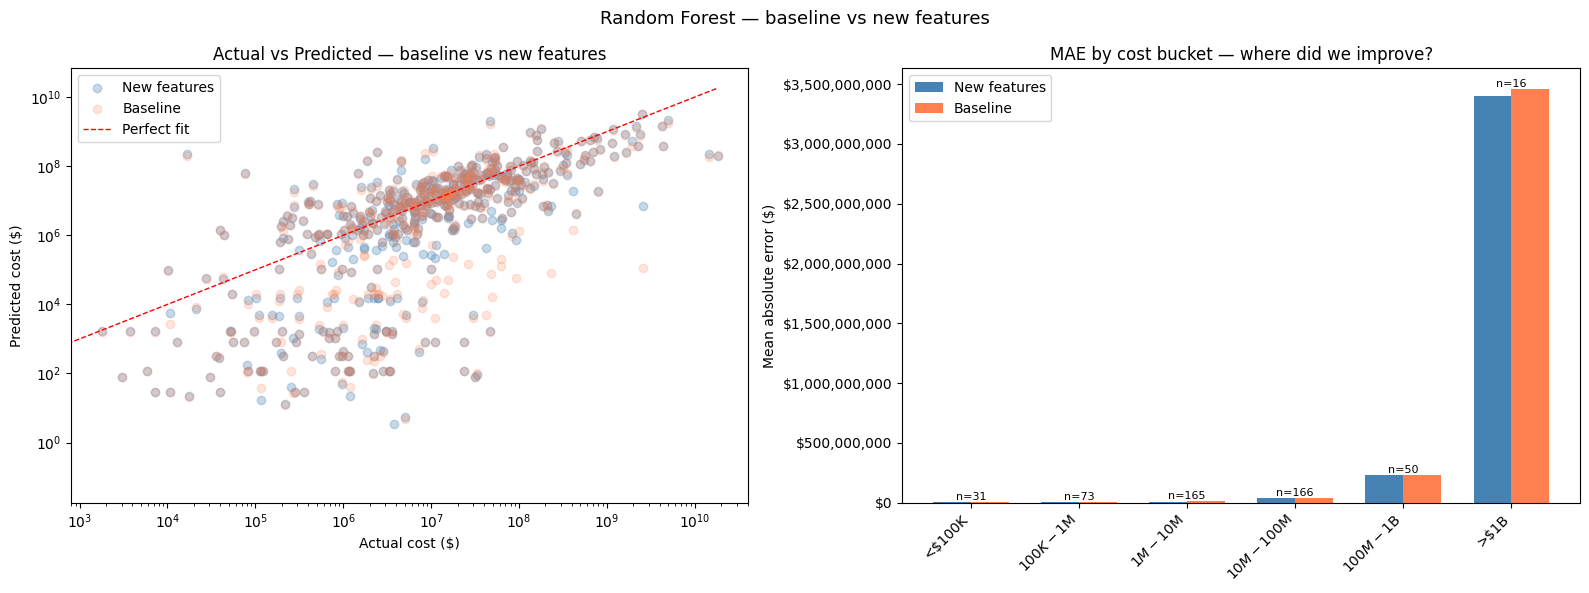

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test_new)

# ── Plot 1 — Actual vs Predicted comparison ────────────────────────────────
ax = axes[0]
ax.scatter(y_test_dollars, y_pred_dollars, alpha=0.3, color='steelblue', label='New features')

# Overlay baseline predictions if available
if 'pipeline' in results.get('random_forest', {}):
    y_pred_baseline = np.expm1(results['random_forest']['pipeline'].predict(X_test_new))
    ax.scatter(y_test_dollars, y_pred_baseline, alpha=0.2, color='coral', label='Baseline')

max_val = max(y_test_dollars.max(), y_pred_dollars.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect fit')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Actual cost ($)')
ax.set_ylabel('Predicted cost ($)')
ax.set_title('Actual vs Predicted — baseline vs new features')
ax.legend()

# ── Plot 2 — Error comparison by cost bucket ───────────────────────────────
ax = axes[1]

# Bucket actual costs and compare MAE per bucket
buckets = [1e3, 1e5, 1e6, 1e7, 1e8, 1e9, 1e11]
bucket_labels = ['<$100K', '$100K-$1M', '$1M-$10M', '$10M-$100M', '$100M-$1B', '>$1B']

new_errors      = np.abs(y_test_dollars.values - y_pred_dollars)
baseline_errors = np.abs(y_test_dollars.values - y_pred_baseline) if 'pipeline' in results.get('random_forest', {}) else None

new_bucket_mae      = []
baseline_bucket_mae = []
bucket_counts       = []

for i in range(len(buckets) - 1):
    mask = (y_test_dollars.values >= buckets[i]) & (y_test_dollars.values < buckets[i+1])
    bucket_counts.append(mask.sum())
    new_bucket_mae.append(np.mean(new_errors[mask]) if mask.sum() > 0 else 0)
    if baseline_errors is not None:
        baseline_bucket_mae.append(np.mean(baseline_errors[mask]) if mask.sum() > 0 else 0)

x = np.arange(len(bucket_labels))
width = 0.35

ax.bar(x - width/2, new_bucket_mae, width, label='New features', color='steelblue')
if baseline_errors is not None:
    ax.bar(x + width/2, baseline_bucket_mae, width, label='Baseline', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(bucket_labels, rotation=45, ha='right')
ax.set_ylabel('Mean absolute error ($)')
ax.set_title('MAE by cost bucket — where did we improve?')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

# Add count labels
for i, count in enumerate(bucket_counts):
    ax.text(x[i], max(new_bucket_mae[i],
            baseline_bucket_mae[i] if baseline_errors is not None else 0),
            f'n={count}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Random Forest — baseline vs new features', fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
# Who are the >$1B disasters in test set?
mask = y_test_dollars >= 1e9
high_cost_test = df.loc[y_test_new.index[mask],
                        ['fyDeclared', 'incidentType',
                         'declarationType', 'state',
                         'total_disaster_cost']].copy()
high_cost_test['predicted'] = y_pred_dollars[mask.values]
high_cost_test['error'] = np.abs(
    y_test_dollars.values[mask.values] - y_pred_dollars[mask.values]
)
print(high_cost_test.sort_values('total_disaster_cost', ascending=False).to_string())

      fyDeclared    incidentType declarationType state  total_disaster_cost     predicted         error
2876        2020      Biological              DR    NY         1.818132e+10  1.950387e+08  1.798628e+10
2881        2020      Biological              DR    TX         1.440937e+10  2.183650e+08  1.419100e+10
3007        2021       Hurricane              DR    LA         4.910270e+09  2.108532e+09  2.801739e+09
2882        2020      Biological              DR    FL         4.399094e+09  3.952096e+08  4.003885e+09
3069        2022       Hurricane              DR    FL         4.205322e+09  1.448784e+09  2.756538e+09
3223        2024  Tropical Storm              DR    NC         2.600459e+09  7.225672e+06  2.593233e+09
3067        2022       Hurricane              DR    PR         2.478359e+09  3.341261e+09  8.629016e+08
3230        2025       Hurricane              DR    FL         2.404665e+09  8.727595e+08  1.531905e+09
2880        2020      Biological              DR    LA         2

In [36]:
# Known catastrophic event signatures based on the 16 failures
# These are the conditions that should trigger LOW confidence flags

# Biological DR — COVID-scale events
df['is_biological_dr'] = (
    (df['incidentType'] == 'Biological') &
    (df['declarationType'] == 'DR')
).astype(int)

# High population state + Hurricane/Tropical Storm DR
# NC, FL, TX, LA, GA all appear in the failure list
high_exposure_states = ['FL', 'TX', 'LA', 'NC', 'NY', 'GA', 'PR', 'VA', 'MI']

df['is_high_exposure_hurricane'] = (
    (df['incidentType'].isin(['Hurricane', 'Tropical Storm'])) &
    (df['declarationType'] == 'DR') &
    (df['state'].isin(high_exposure_states))
).astype(int)

# PR earthquake — unique vulnerability
df['is_pr_earthquake'] = (
    (df['incidentType'] == 'Earthquake') &
    (df['state'] == 'PR')
).astype(int)

# Composite catastrophe risk score
df['catastrophe_risk_score'] = (
    df['is_biological_dr'] * 5 +          # highest risk — COVID scale
    df['is_high_exposure_hurricane'] * 3 + # very high risk
    df['is_pr_earthquake'] * 2 +           # high risk
    (df['programs_activated'] == 4).astype(int) * 2 +  # all programs = major event
    (df['area_bin_score_dr'] >= 4).astype(int)         # large geographic scope
)

# Confidence tiers
def get_confidence(score):
    if score >= 7:
        return 'VERY LOW — likely catastrophic event beyond model range'
    elif score >= 4:
        return 'LOW — significant uncertainty, treat as lower bound'
    elif score >= 2:
        return 'MEDIUM — model has limited precedent for this combination'
    else:
        return 'HIGH — within model training distribution'

df['confidence_tier'] = df['catastrophe_risk_score'].apply(get_confidence)

# Validate — do the 16 failures get flagged correctly?
test_failures = df.loc[y_test_new.index[y_test_dollars >= 1e9]]
print("Catastrophe risk scores for the 16 failures:")
print(test_failures[['incidentType', 'state', 'fyDeclared',
                      'catastrophe_risk_score', 'confidence_tier',
                      'total_disaster_cost']].sort_values(
    'catastrophe_risk_score', ascending=False
).to_string())

print(f"\nFlagged as LOW or VERY LOW confidence: "
      f"{(test_failures['catastrophe_risk_score'] >= 4).sum()} / 16")

Catastrophe risk scores for the 16 failures:
        incidentType state  fyDeclared  catastrophe_risk_score                                            confidence_tier  total_disaster_cost
2890      Biological    MI        2020                       6        LOW — significant uncertainty, treat as lower bound         1.626602e+09
2880      Biological    LA        2020                       6        LOW — significant uncertainty, treat as lower bound         2.269445e+09
2881      Biological    TX        2020                       6        LOW — significant uncertainty, treat as lower bound         1.440937e+10
2882      Biological    FL        2020                       6        LOW — significant uncertainty, treat as lower bound         4.399094e+09
2908      Biological    VA        2020                       6        LOW — significant uncertainty, treat as lower bound         1.129084e+09
2883      Biological    NC        2020                       6        LOW — significant uncertain

In [37]:
print("\nConfidence tier distribution across full dataset:")
print(df['confidence_tier'].value_counts())

print("\nMedian actual cost by confidence tier:")
print(df.groupby('confidence_tier')['total_disaster_cost'].median().sort_values(ascending=False))


Confidence tier distribution across full dataset:
confidence_tier
HIGH — within model training distribution                    3629
MEDIUM — model has limited precedent for this combination     176
LOW — significant uncertainty, treat as lower bound           135
Name: count, dtype: int64

Median actual cost by confidence tier:
confidence_tier
LOW — significant uncertainty, treat as lower bound          3.253034e+08
MEDIUM — model has limited precedent for this combination    2.408897e+07
HIGH — within model training distribution                    1.197806e+06
Name: total_disaster_cost, dtype: float64


In [38]:
test_failures = df.loc[y_test_new.index[y_test_dollars >= 1e9]]

print("16 catastrophic failures — confidence tiers:")
print(test_failures[['incidentType', 'state', 'fyDeclared',
                      'catastrophe_risk_score',
                      'confidence_tier',
                      'total_disaster_cost']
].sort_values('catastrophe_risk_score', ascending=False).to_string())

flagged = (test_failures['catastrophe_risk_score'] >= 4).sum()
print(f"\nCorrectly flagged LOW or above: {flagged} / 16")

# Also check — of the HIGH confidence predictions, how bad are errors?
high_conf_mask = df.loc[y_test_new.index, 'confidence_tier'] == \
                 'HIGH — within model training distribution'

high_conf_errors = np.abs(
    y_test_dollars.values[high_conf_mask.values] -
    y_pred_dollars[high_conf_mask.values]
)

print(f"\nHIGH confidence predictions only:")
print(f"MAE    : ${np.mean(high_conf_errors):,.0f}")
print(f"Median : ${np.median(high_conf_errors):,.0f}")
print(f"Count  : {high_conf_mask.sum()}")

16 catastrophic failures — confidence tiers:
        incidentType state  fyDeclared  catastrophe_risk_score                                            confidence_tier  total_disaster_cost
2890      Biological    MI        2020                       6        LOW — significant uncertainty, treat as lower bound         1.626602e+09
2880      Biological    LA        2020                       6        LOW — significant uncertainty, treat as lower bound         2.269445e+09
2881      Biological    TX        2020                       6        LOW — significant uncertainty, treat as lower bound         1.440937e+10
2882      Biological    FL        2020                       6        LOW — significant uncertainty, treat as lower bound         4.399094e+09
2908      Biological    VA        2020                       6        LOW — significant uncertainty, treat as lower bound         1.129084e+09
2883      Biological    NC        2020                       6        LOW — significant uncertain

In [39]:
# How many catastrophic events do you actually have to learn from?
catastrophic_threshold = 1e9  # $1B+

cat_events = df[df['total_disaster_cost'] >= catastrophic_threshold]
print(f"Total catastrophic events (>$1B): {len(cat_events)}")
print(f"\nBy incident type:")
print(cat_events['incidentType'].value_counts())
print(f"\nBy year:")
print(cat_events['fyDeclared'].value_counts().sort_index())
print(f"\nAs % of total dataset: {len(cat_events)/len(df)*100:.1f}%")

Total catastrophic events (>$1B): 51

By incident type:
incidentType
Hurricane         25
Biological        20
Fire               2
Severe Storm       1
Flood              1
Earthquake         1
Tropical Storm     1
Name: count, dtype: int64

By year:
fyDeclared
2001     1
2004     2
2005     4
2006     1
2008     3
2013     2
2016     1
2017     4
2018     1
2019     2
2020    22
2021     1
2022     2
2024     4
2025     1
Name: count, dtype: int64

As % of total dataset: 1.3%
